# Автоматизация обработки данных сервиса Яндекс Книги в Airflow


## Цели и задачи проекта

Настроить автоматизированный пайплайн обработки пользовательской активности сервиса Яндекс Книги с использованием Apache Airflow и PySpark.

Пайплайн должен ежедневно проверять появление новых данных в объектном хранилище, запускать Spark-задачу для их обработки и сохранять рассчитанные агрегаты в ClickHouse для дальнейшей аналитики и построения отчётности.

## Описание данных

Для создания витрины будут использованы две таблицы:

Таблица `bookmate.audition` содержит данные об активности пользователей и включает столбцы:

Таблица `bookmate.content` включает столбцы:


## Содержимое проекта

Проект предполагает несколько шагов:

1. Написать Spark-код 

2. Создать DAG — он будет запускать Spark-код. В DAG описаны задачи, настроены зависимости 

3. Получить агрегированные данные для дальнейших бизнес-выводов.

## 1. Написание Spark-кода

В коде ниже приведён написанный Spark-скрипт. Ваша задача — правильно указать данные для подключения к вашему хранилищу: порты, параметры кластера ClickHouse и путь, куда будут записываться агрегаты.

In [ ]:
# filename=my_spark_job.py
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import sys

# Создаём Spark-сессию и при необходимости добавляем конфигурации
spark = SparkSession.builder.appName("myAggregateTest").config("fs.s3a.endpoint", "storage.yandexcloud.net").getOrCreate()

# Указываем порт и параметры кластера ClickHouse
jdbcPort = 8443
jdbcHostname = "CLICKHOUSE_HOST.mdb.yandexcloud.net"
username = "CLICKHOUSE_USER"
jdbcDatabase = "CLICKHOUSE_DATABASE"
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"

# Получаем аргумент из Airflow
my_date = sys.argv[1].replace('-', '_')

# Считываем исходные данные за нужную дату
df = spark.read.csv(f"s3a://da-plus-dags/script_bookmate/data_{my_date}/audition_content.csv", inferSchema=True, header=True)

# Строим агрегат по пользователям
result_df = df.groupBy("puid").agg(
    F.countDistinct("audition_id").alias("audition_count"),
    F.avg("hours").alias("avg_hours")
)

result_df.write.format("jdbc") \
    .option("url", jdbcUrl) \
    .option("user", username) \
    .option("password", "aaa111") \
    .option("dbtable", "bookmate_user_aggregate") \
    .mode('append') \
    .save()


В результате создан файл с названием my_spark_job.py. Этот файл будет запущен с помощью Airflow, но сначала настроим DAG.

## 2. Создание DAG


### Первый этап

Создайте основу нового DAG, он должен запускаться каждый день начиная с 1 января 2025 года. При этом запускать DAG за пропущенные даты не нужно.


In [ ]:
# filename=bookmate_dag.py

from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

class PysparkJobOperator(DataprocCreatePysparkJobOperator):
    template_fields = ("cluster_id", "args",)

DAG_ID = "audition_content_analysis"

with DAG(
    DAG_ID,
    schedule="@daily",
    start_date=datetime(2025, 1, 1),
    catchup=False,
) as dag:
  pass

### Второй этап

Добавим проверку входного файла. DAG не должен стартовать, пока в S3 не появится файл с данными за нужную дату.


In [ ]:
# filename=bookmate_dag.py

from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

class PysparkJobOperator(DataprocCreatePysparkJobOperator):
    template_fields = ("cluster_id", "args",)

DAG_ID = "audition_content_analysis"

    wait_for_input = S3KeySensor(
        task_id="data_s3_sensor",
        poke_interval=60*5,
        timeout=60*60,
        bucket_name="da-plus-dags",
        bucket_key="script_bookmate/data_{{ ds.replace('-', '_') }}/audition_content.csv",
        mode="poke",
        aws_conn_id="s3",
        wildcard_match=False,
    )

### Третий этап

Создадим задачу для запуска Spark-скрипта через Airflow.

In [ ]:
# filename=bookmate_dag.py

from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

    run_pyspark = PysparkJobOperator(
        task_id="create_pyspark_job",
        name="create_aggregate_and_load_to_ch",
        cluster_id="CLUSTER_ID",
        args=["{{ ds }}"],
        main_python_file_uri="s3a://da-plus-dags/CLICKHOUSE_USER/jobs/my_spark_job.py",
    )

### Четвертый этап 

Финальная сборка:

* Опишим DAG с нужными параметрами.

* Добавим сенсор для ожидания входного файла.

* Добавим Spark-задачу для запуска скрипта.

* Настроим зависимости так, чтобы Spark-задача запускалась только после появления файла.

In [ ]:
# filename=bookmate_dag.py

from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

class PysparkJobOperator(DataprocCreatePysparkJobOperator):
    template_fields = ("cluster_id", "args",)

DAG_ID = "audition_content_analysis3"

with DAG(
    DAG_ID,
    schedule="@daily",
    start_date=datetime(2025, 1, 1),
    catchup=False,
) as dag:

    # 1) Ждём появления входного файла в S3
    wait_for_input = S3KeySensor(
        task_id="data_s3_sensor",
        poke_interval=60*5,
        timeout=60*60,
        bucket_name="da-plus-dags",
        bucket_key="script_bookmate/data_{{ ds.replace('-', '_') }}/audition_content.csv",
        mode="poke",
        aws_conn_id="s3",
        wildcard_match=False,
    )

    # 2) Запускаем PySpark-задание на кластере Dataproc
    run_pyspark = PysparkJobOperator(
        task_id="create_pyspark_job",
        name="create_aggregate_and_load_to_ch",
        cluster_id="CLUSTER_ID",
        args=["{{ ds }}"],
        main_python_file_uri="s3a://da-plus-dags/CLICKHOUSE_USER/jobs/my_spark_job.py",
    )

    # 3) Задаём зависимости
    wait_for_input >> run_pyspark

## 3. Запуск Airflow

Переходим к запуску.

Проверяем, что DAG выполнился и результат соответствует ожиданиям.

Результат запроса из DBeaver

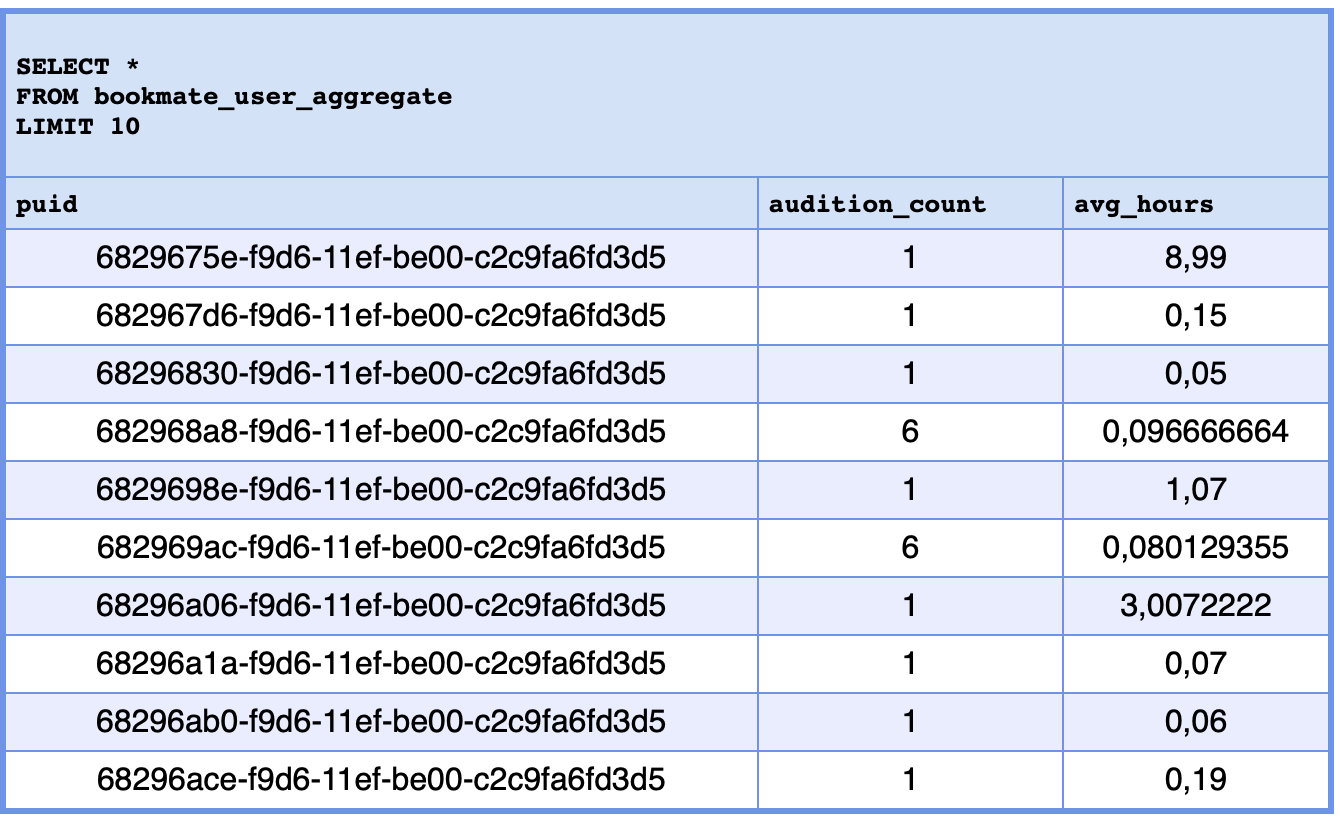

Проверяем данные из clickhouse

In [1]:
!pip install clickhouse_connect -q

import clickhouse_connect

username="CLICKHOUSE_USER"
password="aaa111"

client = clickhouse_connect.get_client(
    host="CLICKHOUSE_HOST.mdb.yandexcloud.net",
    port=8443,
    username=username,
    password=password,
    secure=True,
    verify=False,
    database="CLICKHOUSE_DATABASE" + username,
)


count_query = (
    f"SELECT count() FROM playground_{username}.bookmate_user_aggregate"
)
result = client.query(count_query)
row_count = result.result_rows[0][0]
print("Количество строк в таблице:", row_count)

Количество строк в таблице: 2163


/tmp/ipykernel_85/194246588.py:3: DeprecationWarning: Python 3.9 support is deprecated and will be removed in a future release. This version of clickhouse-connect may stop working with Python 3.9 unexpectedly.
  import clickhouse_connect
